# Does a JITAI prompt help *right now*? 

A guided WCLS analysis of the REACT micro-randomized trial

Author: Tien Tyler Le

Updated: 07/27/2026

This notebook walks through the primary Micro-Randomized Trial analysis, from the causal question to a result we can report. 

The long-form background is in `analysis-resources/wcls-explainer.md`.

## **Goal**

the proximal causal effect of sending a prompt on the next check-in's mood
(`B1_valence`) and stress (`B2_stress`), and how that effect changes with time of day, week of study and
baseline volatility. It is estimated with **WCLS** (weighted and centered least squares, Boruvka et al. 2018)
and compared against **GEE**, the method most analysts would reach for first (Boruvlka et al. 2018).

### Roadmap

| § | Step | Question it answers |
|---|---|---|
| 1 | The causal question | What exactly are we estimating, and why does randomization let us? |
| 2 | Setup | — |
| 3 | Data | Synthetic cohort with a known effect, or the live database |
| 4 | Decision-point table | How do production tables become one row per randomization? Is the data trustworthy? |
| 5 | The WCLS estimator | How do centering, weighting and the sandwich work? |
| 6 | The GEE baseline | What does the "usual" repeated-measures analysis look like? |
| 7 | Results | What are the effects, and do WCLS and GEE agree? |
| 8 | Evaluating the implementation | Is the code right? When does GEE go wrong and WCLS not? Is the study powered? |
| 9 | Sensitivity | Does the answer depend on the outcome definition? |
| 10 | Wrap-up | Limitations and the checklist for a live run |

### How to run it

- **`DATA_SOURCE = "synthetic"`** (the default) runs everything on a simulated cohort whose true effect is
  known. Use it to learn the pipeline and to check that the code recovers the truth.
- **`DATA_SOURCE = "live"`** reads the REACT database through the `scripts.load_*` loaders. They only
  SELECT, but **your local `.env` points at production**. 
  
  NOTE: This is real participant data, so keep outputs out of git and within IRB scope.

- **`DESIGN_CUTOVER`** is the time the fixed-lag outcome design went live (for example
  `"2026-10-01 00:00"`, UTC). Leave it `None` for synthetic data. On live data, decision points before it
  used the old post-prompt-only design and are analyzed separately (§9.2).

- **`RUN_MONTE_CARLO`** / **`MC_REPS`** control §8's simulation study. Together with §8e's power check it takes about 6-7
  minutes.
- Run top to bottom (*Restart & Run All*).

-----------

## 1. The causal question

### 1.1 What would have happened otherwise?

An arbitrary participant finishes a check-in at 3:10 pm, the engine finds them eligible, and the coin (randomized part of MRT) says **send**.
Their next check-in, 90 minutes later, shows valence = 5. Did the prompt help?

To know, we'd need what that check-in would have said **without** the prompt. Causal inference calls these
the two **potential outcomes**:

- $Y(1)$: next check-in valence **if we send**
- $Y(0)$: next check-in valence **if we don't**

-- *The notation in Boruvka et al. denote this as a Boolean variable, $A_t \in [0, 1]$*

The effect of this prompt is $Y(1) - Y(0)$, but we only ever observe one of the two. This is the
*fundamental problem of causal inference*.

### 1.2 What randomization buys

*We refer micro-randonmization here as 'coin'.*

We can't see both outcomes for one moment. But we can compare many sent moments with many unsent ones,
as long as the two groups are alike in everything except the prompt. **A coin guarantees that.** Sent
moments aren't systematically later in the day, moodier or more engaged than unsent ones. So **on average**
the difference in outcomes is the causal effect.

> **Key idea for the rest of the notebook:** in an observational study you add control variables to remove
> confounding. In a randomized study the coin already removed it, so **controls are only there to reduce
> noise, not to make the answer correct.** Weighted and Center Least Squares is built around this fact.

### 1.3 Why an MRT is different from an ordinary trial

REACT flips a coin at *every available decision point*, hundreds per person over the season. That brings
four complications:

| Complication | What it looks like in REACT |
|---|---|
| Repeated measures | Rows from the same person are correlated: a generally happy person is happy at many moments. |
| Treatment changes the future | A 3 pm prompt changes the next check-in, which is the *next* decision point. Its valence becomes that row's `prior_valence` and feeds the MSSD that decides eligibility. |
| Availability | Run-in, below-threshold, cooldown and cap moments were never randomized. The effect only exists for available moments. |
| Effects can vary | A prompt may help more in the evening, early in the season, or for more volatile people. |

### 1.4 The estimand: the causal excursion effect

Let the study run normally up to 3 pm. At 3 pm, step outside the protocol: force "send" in one copy of the
world and "don't send" in another, then compare the next check-in:

$$
\beta = \mathbb{E}\big[\,Y_{t+1}(\text{send now}) - Y_{t+1}(\text{don't send now}) \;\big|\; \text{available}\,\big]
$$

**Note: in Boruvka et al. 'send now' and 'don't send now' are denoted as [0, 1]**

The average is over all the histories the real study produces. It is an *excursion*: a one-moment departure
from the protocol, **not** "always send vs. never send". With a moderator $S$ (such as hour of day),
$\beta(S)$ is the same effect averaged separately at each value of $S$. With 35 people we can't estimate
an effect for every possible situation, but we can estimate it averaged over everything except a few
chosen moderators. That is also what a JITAI designer needs.

## 2. Setup

In [1]:
import sys
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
from statsmodels.genmod.cov_struct import Autoregressive, Exchangeable, Independence
import matplotlib.pyplot as plt

ANALYTICS_DIR = Path.cwd() if (Path.cwd() / "scripts.py").exists() else Path.cwd() / "analytics"
sys.path.insert(0, str(ANALYTICS_DIR))

import scripts
from dashboard.data.config import (
    OUTCOME_CHECK_IN_DELAY_MINUTES,
    OUTCOME_WINDOW_HOURS,
    PARTICIPANT_TZ,
    RANDOMIZATION_P_DEFAULT,
    RUN_IN_DAYS,
    STUDY_DAYS,
)

SIGNAL_SUB_ITEMS = ("B1_valence", "B2_stress", "B1_arousal")
HOUR_CENTER = 15.0
DAY_CENTER = (RUN_IN_DAYS + STUDY_DAYS - 1) / 2

DATA_SOURCE = "synthetic"
DESIGN_CUTOVER = None
RUN_MONTE_CARLO = True
MC_REPS = 200

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
print(f"OUTCOME_WINDOW_HOURS={OUTCOME_WINDOW_HOURS}  OUTCOME_CHECK_IN_DELAY_MINUTES={OUTCOME_CHECK_IN_DELAY_MINUTES}  RUN_IN_DAYS={RUN_IN_DAYS}  STUDY_DAYS={STUDY_DAYS}  "
      f"p_default={RANDOMIZATION_P_DEFAULT}  tz={PARTICIPANT_TZ}")

OUTCOME_WINDOW_HOURS=2  OUTCOME_CHECK_IN_DELAY_MINUTES=60  RUN_IN_DAYS=7  STUDY_DAYS=35  p_default=0.5  tz=America/New_York


The constants come from `backend/dashboard/data/config.py`, the single authority for study constants, so
the 2-hour outcome window, the 7-day run-in and the Eastern timezone here are the same values the Celery
engine uses.

## 3. Data

### 3a. A synthetic cohort with a known answer

The simulated cohort's tables have the same columns, sub-item ids and 1–7 integer Likert values as
production. It exists so we can check the method against a known truth. The data-generating process follows
the real pipeline:

| Feature | How it is simulated |
|---|---|
| Check-ins | 6 scheduled slots a day (09–19 Eastern). About 80 % are completed, submitted 5–75 min into the slot. |
| Decision points | Every completed check-in is one. The decision lands 1–3 min after submission. |
| Availability | None during the 7-day run-in. Afterwards eligibility is 60 % after a volatile check-in and 30 % after a calm one, so availability depends on past outcomes, like the MSSD gate. |
| Randomization | $p = 0.5$ by default; §8 also uses a time-varying $p$. |
| **Outcome check-in** | The design as built: every available decision point, sent or not, gets a linked outcome check-in from +60 to +105 min (+60 is `OUTCOME_CHECK_IN_DELAY_MINUTES`), completed 75 % of the time **in both arms**. A scheduled check-in that would fall in an open window is not served, just as `/ema/next/` holds it back. |
| **True effect** | On the outcome check-in: valence $+0.40 + 0.05\,(\text{hour} - 15)$; stress $-0.30$. |
| Time-of-day pattern | Valence rises by 0.08 per hour, so evenings are happier regardless of any prompt. |
| Carryover | Half of each effect persists into the person's latent mood, so today's prompt shifts later covariates (the feedback loop in §1.3). |
| Legacy design | `design="legacy"` reproduces the build before the fix, where only a delivered prompt opened a window: treated-only post-prompt check-ins, reminders suppressed after a send (completion 0.65 vs 0.80), and outcomes read from the next scheduled check-in. It is used only in §8c (scenario 3b) and §9. |

For every decision the simulator also records **both potential outcomes** of its outcome check-in: the rounded
value with the effect and the rounded value without it. Their average difference is the exact
*observed-scale* truth. Rounding to a 1–7 scale makes the observed effect slightly different from the latent
+0.40, so the notebook always compares against this observed-scale truth.

In [2]:
# Generating our Synthetic cohort, imitating dress rehearsal. 
# Future updates to this notebook should reference a single synthetic data generator, but for the sake of simplicity, we define the data below. 

## Truth variables
TRUE_EFFECTS = dict(valence_at_15h   = 0.40, 
                    valence_per_hour = 0.05, 
                    stress           = -0.30)


def _likert(x):
    return np.clip(np.rint(x), 1, 7).astype(int)


def simulate_cohort(n_users=30, seed=0, p_fn=None, beta_valence=(TRUE_EFFECTS["valence_at_15h"], TRUE_EFFECTS["valence_per_hour"]),
                    beta_stress=TRUE_EFFECTS["stress"], beta_prior=0.0, diurnal=0.08, carryover=0.5,
                    eligible_calm=0.30, eligible_volatile=0.60, completion=0.80, outcome_completion=0.75,
                    design="fixed_lag", completion_suppressed=0.65, post_prompt_rate=0.60, study_start="2026-08-24"):
    rng = np.random.default_rng(seed)
    p_fn = p_fn or (lambda hour: RANDOMIZATION_P_DEFAULT)
    window = pd.Timedelta(hours=OUTCOME_WINDOW_HOURS)
    lag = pd.Timedelta(minutes=OUTCOME_CHECK_IN_DELAY_MINUTES)
    day0 = pd.Timestamp(study_start, tz=PARTICIPANT_TZ)
    users, ema, items, jitai, truth = [], [], [], [], []
    ema_id = item_id = jid = 0

    def add_ema(uid, sent_at, ema_type, val, strs, aro, source=None):
        nonlocal ema_id, item_id
        ema_id += 1
        ema.append(dict(id=ema_id, user_id=uid, prompt_id=f"{ema_type}-{ema_id}", sent_at=sent_at,
                        responded_at=sent_at, status="completed", ema_type=ema_type,
                        source_jitai_log_id=source, mood=None, stress=None, energy=None))
        for sub, v in zip(SIGNAL_SUB_ITEMS, (val, strs, aro)):
            item_id += 1
            items.append(dict(id=item_id, ema_id=ema_id, item_id=sub.split("_")[0], sub_item_id=sub,
                              response_type="likert", value_numeric=int(v), value_choice=None,
                              value_choices=None, user_id=uid, sent_at=sent_at))
        return ema_id

    def effect(pending):
        dv = beta_valence[0] + beta_valence[1] * (pending["hour"] - HOUR_CENTER) + beta_prior * (4 - pending["v"])
        return dv, beta_stress

    for uid in range(1, n_users + 1):
        enrolled = day0 + pd.Timedelta(days=int(rng.integers(0, 3)), hours=10)
        users.append(dict(user_id=uid, enrolled_at=enrolled.tz_convert("UTC"), is_enrolled=True))
        mu_v, mu_s, mu_a = rng.uniform(3.5, 5.0), rng.uniform(2.5, 4.0), rng.uniform(3.0, 4.5)
        sd, rho = rng.uniform(0.8, 1.4), rng.uniform(0.2, 0.6)
        innovation = sd * np.sqrt(1 - rho ** 2)
        z = np.zeros(3)
        pending = None
        last_v = None
        day1 = enrolled.normalize()

        def latent(when, state):
            when_hour = when.hour + when.minute / 60
            return mu_v + diurnal * (when_hour - HOUR_CENTER) + state[0], mu_s + state[1], mu_a + state[2]

        for d in range(STUDY_DAYS):
            for k in range(6):
                z = rho * z + rng.normal(0, innovation, 3)
                slot = day1 + pd.Timedelta(days=d, hours=9 + 2 * k)
                sent = slot + pd.Timedelta(minutes=float(rng.uniform(5, 75)))
                in_window = pending is not None and pending["anchor"] < sent <= pending["anchor"] + window
                if design == "fixed_lag" and in_window and pending["available"]:
                    continue
                p_done = completion_suppressed if (design == "legacy" and in_window and pending["A"] == 1) else completion
                if rng.random() >= p_done:
                    continue
                lat_v, lat_s, lat_a = latent(sent, z)
                dv = ds = 0.0
                a_obs = 0
                if design == "legacy" and in_window:
                    dv, ds = effect(pending)
                    truth.append(dict(jitai_log_id=pending["jid"],
                                      true_dv=int(_likert(lat_v + dv) - _likert(lat_v)),
                                      true_ds=int(_likert(lat_s + ds) - _likert(lat_s))))
                    a_obs = pending["A"]
                v, s, a = _likert(lat_v + a_obs * dv), _likert(lat_s + a_obs * ds), _likert(lat_a)
                z[0] += carryover * a_obs * dv
                z[1] += carryover * a_obs * ds
                eid = add_ema(uid, sent.tz_convert("UTC"), "scheduled_check_in", v, s, a)

                anchor = sent + pd.Timedelta(minutes=float(rng.uniform(1, 3)))
                hour = anchor.hour + anchor.minute / 60
                study_day = (anchor.normalize() - day1).days
                volatile = last_v is not None and abs(v - last_v) >= 1
                last_v = v
                engine_eligible = rng.random() < (eligible_volatile if volatile else eligible_calm)
                in_run_in = study_day < RUN_IN_DAYS
                eligible = engine_eligible and not in_run_in
                p = float(p_fn(hour))
                draw = float(rng.random()) if eligible else None
                A = int(eligible and draw < p)
                reason = ("run-in period" if engine_eligible and in_run_in
                          else "prompt sent" if eligible
                          else "below within-person threshold")
                jid += 1
                jitai.append(dict(id=jid, user_id=uid, decision_point_id=f"ema_{eid}", ema_id=eid,
                                  decision_made_at=anchor.tz_convert("UTC"), trigger_reason=reason,
                                  randomization_probability=p, randomization_draw=draw,
                                  send_prompt=bool(A), threshold_source="engine",
                                  ema_mood=int(v), ema_stress=int(s), ema_energy=int(a)))
                pending = dict(anchor=anchor, A=A, hour=hour, jid=jid, v=v, available=eligible)

                if design == "fixed_lag" and eligible and rng.random() < outcome_completion:
                    out_at = anchor + lag + pd.Timedelta(minutes=float(rng.uniform(0, 45)))
                    z_out = rho * z + rng.normal(0, innovation, 3)
                    ov, os_, oa = latent(out_at, z_out)
                    dv, ds = effect(pending)
                    truth.append(dict(jitai_log_id=jid, true_dv=int(_likert(ov + dv) - _likert(ov)),
                                      true_ds=int(_likert(os_ + ds) - _likert(os_))))
                    kind = "extra_check_in" if rng.random() < 0.5 else "post_prompt"
                    add_ema(uid, out_at.tz_convert("UTC"), kind, _likert(ov + A * dv), _likert(os_ + A * ds),
                            _likert(oa), source=jid)
                    z[0] += carryover * A * dv
                    z[1] += carryover * A * ds
                elif design == "legacy" and A and rng.random() < post_prompt_rate:
                    dv, ds = effect(pending)
                    pp_sent = anchor + pd.Timedelta(minutes=float(rng.uniform(10, 100)))
                    add_ema(uid, pp_sent.tz_convert("UTC"), "post_prompt", _likert(lat_v + dv + rng.normal(0, 0.3)),
                            _likert(lat_s + ds + rng.normal(0, 0.3)), _likert(lat_a), source=jid)

    frames = dict(users=pd.DataFrame(users), ema=pd.DataFrame(ema).sort_values("sent_at", ignore_index=True),
                  items=pd.DataFrame(items), jitai=pd.DataFrame(jitai))
    for col in ("sent_at", "responded_at"):
        frames["ema"][col] = pd.to_datetime(frames["ema"][col], utc=True)
    frames["items"]["sent_at"] = pd.to_datetime(frames["items"]["sent_at"], utc=True)
    frames["jitai"]["decision_made_at"] = pd.to_datetime(frames["jitai"]["decision_made_at"], utc=True)
    frames["users"]["enrolled_at"] = pd.to_datetime(frames["users"]["enrolled_at"], utc=True)
    return frames, pd.DataFrame(truth)

### 3b. Loading the live database

`scripts.load_jitai_log` does not select `threshold_source`, so it is joined on here by id. Only `user_id`
and `enrolled_at` are kept from `load_users`; email and names are dropped immediately. Only the JITAI frame
is date-filtered, because a decision's outcome can fall after `end_date`.

In [3]:
def load_live(start_date=None, end_date=None):
    scripts._ensure_django()
    from app.models import JITAILog

    jitai = scripts.load_jitai_log(start_date=start_date, end_date=end_date)
    source = pd.DataFrame(JITAILog.objects.values("id", "threshold_source"))
    jitai = jitai.merge(source, on="id", how="left") if not source.empty else jitai.assign(threshold_source=None)
    users = scripts.load_users()[["user_id", "enrolled_at"]]
    return dict(users=users, ema=scripts.load_ema(), items=scripts.load_ema_item_responses(), jitai=jitai)

## 4. From production tables to one row per decision point

Every analysis step works on a table with **one row per randomization opportunity**. `_evaluate_user`
already writes exactly one `JITAILog` row per scored EMA, eligible or not, so nothing needs reconstructing.
The builder turns each row into:

| Column | Meaning | Built from | Why this way |
|---|---|---|---|
| `available` | Was this moment randomized? | `randomization_draw` is not null | Unavailable moments have no draw. They were never randomized and carry no causal information. |
| `A` | Treatment | `randomization_draw < randomization_probability` | **The coin, not `send_prompt`.** `send_prompt` flips back to False when routing finds no prompt, and stays True when the push fails, so it is not the randomized quantity. This is intention-to-treat. |
| `p` | P(coin says send) | `randomization_probability` | Logged on every row, so a mid-season change is handled automatically. |
| `anchor` | When the decision happened | `decision_made_at` | Beat runs every 180 s, and backlogs can make it late, so outcomes are timed from the decision, not the EMA. |
| `y` | Proximal outcome | the first completed outcome check-in **linked to this decision** (`source_jitai_log_id`, type `post_prompt`/`extra_check_in`) with `anchor + 60 min ≤ sent_at ≤ anchor + 2 h`, read from `EMAItemResponse` | **Measured the same way in both arms.** `/ema/next/` opens the same window after every available decision point, sent or not (protocol §9.2), and the participant is notified at +60 min if they haven't answered. `EMA.mood/stress/energy` are never filled in by the submit path. |
| `prior_valence`, `prior_stress` | State at the decision | the decision EMA's own sub-items | Strong predictors of `y`; used as noise-absorbing controls. |
| `hour_c`, `day_c` | Moderators / controls | Eastern hour − 15; study day − mid-study | Study day follows the same rule as `_in_run_in`. Centering makes $\beta_0$ "the effect at 3 pm, mid-study". |
| `mssd_c` | Moderator | run-in-week MSSD of the engine's signal, centered | Does the prompt work differently for more volatile people? |

Only engine-written rows are kept (`decision_point_id` starting `ema_` and `threshold_source == 'engine'`).
Rows posted by a client through `POST /jitai/` are not randomizations.

In [4]:
def signal_wide(items):
    sub = items[items["sub_item_id"].isin(SIGNAL_SUB_ITEMS)]
    wide = sub.pivot_table(index="ema_id", columns="sub_item_id", values="value_numeric", aggfunc="first")
    return wide.reindex(columns=list(SIGNAL_SUB_ITEMS)).astype(float)


def _local_day(ts):
    return ts.dt.tz_convert(PARTICIPANT_TZ).dt.tz_localize(None).dt.normalize()


OUTCOME_EMA_TYPES = ("post_prompt", "extra_check_in")


def build_decision_points(jitai, ema, items, users, outcome_item="B1_valence", outcome_definition="linked",
                          window_hours=OUTCOME_WINDOW_HOURS, delay_minutes=OUTCOME_CHECK_IN_DELAY_MINUTES):
    wide = signal_wide(items)
    j = jitai[jitai["decision_point_id"].astype(str).str.startswith("ema_")]
    j = j[j["threshold_source"].eq("engine")]
    dp = j.rename(columns={"id": "jitai_log_id", "ema_id": "decision_ema_id"})[
        ["jitai_log_id", "user_id", "decision_point_id", "decision_ema_id", "decision_made_at",
         "trigger_reason", "randomization_probability", "randomization_draw", "send_prompt"]
    ].copy()

    dp = dp.merge(ema[["id", "sent_at"]].rename(columns={"id": "decision_ema_id", "sent_at": "decision_ema_sent_at"}),
                  on="decision_ema_id", how="left")
    dp["anchor"] = pd.to_datetime(dp["decision_made_at"], utc=True)
    dp["decision_lag_min"] = (dp["anchor"] - dp["decision_ema_sent_at"]).dt.total_seconds() / 60

    dp["p"] = dp["randomization_probability"].astype(float)
    dp["available"] = dp["randomization_draw"].notna()
    dp["A"] = np.where(dp["available"], (dp["randomization_draw"].astype(float) < dp["p"]).astype(float), np.nan)
    dp["send_disagrees_with_A"] = dp["available"] & (dp["A"].eq(1) != dp["send_prompt"].astype(bool))

    prior = wide[["B1_valence", "B2_stress"]].rename(columns={"B1_valence": "prior_valence", "B2_stress": "prior_stress"})
    dp = dp.merge(prior, left_on="decision_ema_id", right_index=True, how="left")

    local = dp["anchor"].dt.tz_convert(PARTICIPANT_TZ)
    dp["hour"] = local.dt.hour + local.dt.minute / 60
    enrolled = users[["user_id", "enrolled_at"]].copy()
    enrolled["day1"] = _local_day(pd.to_datetime(enrolled["enrolled_at"], utc=True))
    dp = dp.merge(enrolled[["user_id", "day1"]], on="user_id", how="left")
    dp["study_day"] = (_local_day(dp["anchor"]) - dp["day1"]).dt.days
    dp["hour_c"] = dp["hour"] - HOUR_CENTER
    dp["day_c"] = dp["study_day"] - DAY_CENTER

    completed = ema[ema["status"].eq("completed")]
    values = wide[[outcome_item]].dropna()
    if outcome_definition == "linked":
        cand = completed[completed["ema_type"].isin(OUTCOME_EMA_TYPES) & completed["source_jitai_log_id"].notna()]
        cand = cand.merge(values, left_on="id", right_index=True)[["id", "source_jitai_log_id", "sent_at", "ema_type", outcome_item]]
        cand = cand.rename(columns={"id": "outcome_ema_id", "sent_at": "outcome_sent_at", "ema_type": "outcome_ema_type",
                                    outcome_item: "y", "source_jitai_log_id": "jitai_log_id"})
        cand["jitai_log_id"] = cand["jitai_log_id"].astype(int)
        cand["outcome_sent_at"] = pd.to_datetime(cand["outcome_sent_at"], utc=True)
        linked = dp[["jitai_log_id", "anchor"]].merge(cand, on="jitai_log_id")
        lo = linked["anchor"] + pd.Timedelta(minutes=delay_minutes)
        hi = linked["anchor"] + pd.Timedelta(hours=window_hours)
        linked = linked[(linked["outcome_sent_at"] >= lo) & (linked["outcome_sent_at"] <= hi)]
        first = linked.sort_values("outcome_sent_at").drop_duplicates("jitai_log_id").drop(columns="anchor")
        matched = dp.merge(first, on="jitai_log_id", how="left")
    else:
        cand = completed[completed["ema_type"].eq("scheduled_check_in")][["id", "user_id", "sent_at", "ema_type"]]
        cand = cand.merge(values, left_on="id", right_index=True)
        cand = cand.rename(columns={"id": "outcome_ema_id", "sent_at": "outcome_sent_at", "ema_type": "outcome_ema_type",
                                    outcome_item: "y"})
        cand["outcome_sent_at"] = pd.to_datetime(cand["outcome_sent_at"], utc=True)
        matched = pd.merge_asof(dp.dropna(subset=["anchor"]).sort_values("anchor"), cand.sort_values("outcome_sent_at"),
                                left_on="anchor", right_on="outcome_sent_at", by="user_id", direction="forward",
                                allow_exact_matches=False, tolerance=pd.Timedelta(hours=window_hours))
        matched.loc[matched["outcome_ema_id"].eq(matched["decision_ema_id"]), ["y", "outcome_ema_id"]] = np.nan
    matched["outcome_item"] = outcome_item
    matched["outcome_definition"] = outcome_definition
    return matched.sort_values(["user_id", "anchor"], ignore_index=True)

**Sanity check on the outcome window.** Eight tiny hand-built cases pin down the edge behaviour:
- A linked check-in at +59 min is too early; +60 min and +2 h exactly are in; +2 h 1 min is out.
- An unlinked scheduled check-in, or a check-in linked to a different decision, is never the outcome.
- The first linked check-in wins.
- `A` comes from the draw even when `send_prompt` says otherwise.

The cell asserts all eight, so a regression stops the notebook here.

**Live data from before the fix.** Decision points made before the fixed-lag design was deployed have no
linked outcome check-in unless a prompt was sent. Set `DESIGN_CUTOVER` (§2) to the deploy time. The primary
analysis then uses only later decision points, and §9 analyzes the earlier ones separately with the legacy
definition.

In [5]:
t0 = pd.Timestamp("2026-09-01 18:00", tz="UTC")
toy_users = pd.DataFrame([dict(user_id=1, enrolled_at=t0 - pd.Timedelta(days=10))])


def toy_outcome(rows, send_prompt=False, draw=0.2):
    toy_jitai = pd.DataFrame([dict(id=1, user_id=1, decision_point_id="ema_1", ema_id=1, decision_made_at=t0,
                                   trigger_reason="prompt sent", randomization_probability=0.5, randomization_draw=draw,
                                   send_prompt=send_prompt, threshold_source="engine")])
    emas = [dict(id=1, user_id=1, sent_at=t0 - pd.Timedelta(minutes=2), status="completed",
                 ema_type="scheduled_check_in", source_jitai_log_id=None)]
    emas += [dict(id=i + 2, user_id=1, sent_at=t0 + pd.Timedelta(minutes=m), status="completed", ema_type=kind,
                  source_jitai_log_id=link) for i, (m, kind, link) in enumerate(rows)]
    toy_ema = pd.DataFrame(emas)
    toy_items = pd.DataFrame([dict(ema_id=e["id"], sub_item_id=sub, value_numeric=e["id"]) for e in emas for sub in SIGNAL_SUB_ITEMS])
    out = build_decision_points(toy_jitai, toy_ema, toy_items, toy_users).iloc[0]
    return out


def outcome_id(rows):
    value = toy_outcome(rows)["outcome_ema_id"]
    return None if pd.isna(value) else int(value)


window_cases = pd.DataFrame([
    ("linked check-in 59 min after the decision is too early", outcome_id([(59, "post_prompt", 1)]), None),
    ("linked check-in exactly at +60 min is the outcome", outcome_id([(60, "post_prompt", 1)]), 2),
    ("linked check-in exactly at +2 h is the outcome", outcome_id([(120, "extra_check_in", 1)]), 2),
    ("linked check-in at +2 h 1 min is outside the window", outcome_id([(121, "post_prompt", 1)]), None),
    ("an unlinked scheduled check-in inside the window is not the outcome", outcome_id([(70, "scheduled_check_in", None)]), None),
    ("a check-in linked to another decision is not the outcome", outcome_id([(70, "post_prompt", 99)]), None),
    ("the first linked check-in wins", outcome_id([(80, "post_prompt", 1), (70, "extra_check_in", 1)]), 3),
    ("A comes from the draw even though send_prompt=False", toy_outcome([], send_prompt=False, draw=0.2)["A"], 1.0),
], columns=["case", "result", "expected"])
window_cases["pass"] = [(pd.isna(a) and pd.isna(b)) or a == b
                        for a, b in zip(window_cases["result"].astype(object), window_cases["expected"].astype(object))]
assert window_cases["pass"].all(), window_cases
window_cases

,case,result,expected,pass
0,linked check-in 59 min after the decision is t...,NaN,NaN,True
1,linked check-in exactly at +60 min is the outcome,2.0,2.0,True
2,linked check-in exactly at +2 h is the outcome,2.0,2.0,True
3,linked check-in at +2 h 1 min is outside the w...,NaN,NaN,True
4,an unlinked scheduled check-in inside the wind...,NaN,NaN,True
5,a check-in linked to another decision is not t...,NaN,NaN,True
6,the first linked check-in wins,3.0,3.0,True
7,A comes from the draw even though send_prompt=...,1.0,1.0,True


**Baseline MSSD** is the run-in-week MSSD (study days 0–6, Eastern) of the engine's own trigger signal: the
mean of `B1_valence`, `B2_stress` and `B1_arousal` over completed EMAs that carry all three, which is what
`build_decision_frame` scores. It uses `scripts.compute_mssd`. `scripts.compute_run_in_mssd` is *not*
reused, because it filters `item_id in {B1, B2}` and uses a UTC `enrolled_at + 7 days` boundary, which is
neither the production signal nor the `_in_run_in` rule.

In [6]:
def add_baseline_mssd(dp, ema, items, users):
    wide = signal_wide(items).dropna()
    sig = wide.mean(axis=1).rename("signal").reset_index()
    sig = sig.merge(ema[["id", "user_id", "sent_at", "status"]], left_on="ema_id", right_on="id")
    sig = sig[sig["status"].eq("completed")]
    day1 = users[["user_id", "enrolled_at"]].assign(day1=lambda u: _local_day(pd.to_datetime(u["enrolled_at"], utc=True)))
    sig = sig.merge(day1[["user_id", "day1"]], on="user_id")
    sig["study_day"] = (_local_day(pd.to_datetime(sig["sent_at"], utc=True)) - sig["day1"]).dt.days
    run_in = sig[sig["study_day"].between(0, RUN_IN_DAYS - 1)].sort_values("sent_at")
    baseline = run_in.groupby("user_id")["signal"].apply(scripts.compute_mssd).rename("baseline_mssd").reset_index()
    out = dp.drop(columns=[c for c in ("baseline_mssd", "mssd_c") if c in dp]).merge(baseline, on="user_id", how="left")
    out["mssd_c"] = out["baseline_mssd"] - baseline["baseline_mssd"].mean()
    return out

In [7]:
truth = None
if DATA_SOURCE == "synthetic":
    frames, truth = simulate_cohort(n_users=30, seed=2026)
else:
    frames = load_live()

dp_all = build_decision_points(frames["jitai"], frames["ema"], frames["items"], frames["users"])
dp_all = add_baseline_mssd(dp_all, frames["ema"], frames["items"], frames["users"])
cutover = pd.Timestamp(DESIGN_CUTOVER, tz="UTC") if DESIGN_CUTOVER else None
dp = dp_all if cutover is None else dp_all[dp_all["anchor"] >= cutover].reset_index(drop=True)
if cutover is not None:
    print(f"primary analysis uses {len(dp)} decision points at or after the fixed-lag cutover {cutover}; "
          f"{len(dp_all) - len(dp)} earlier ones are legacy (see §9)")
N_PARTICIPANTS = dp.loc[dp.available & dp.y.notna(), "user_id"].nunique()
print(f"source={DATA_SOURCE}  participants={dp.user_id.nunique()}  decision points={len(dp)}  "
      f"available={int(dp.available.sum())}  with outcome={int((dp.available & dp.y.notna()).sum())}")
dp[["user_id", "decision_point_id", "anchor", "trigger_reason", "available", "p", "A", "prior_valence",
    "prior_stress", "hour", "study_day", "baseline_mssd", "outcome_ema_id", "y"]].head(8)

source=synthetic  participants=30  decision points=4421  available=1749  with outcome=1319


,user_id,decision_point_id,anchor,trigger_reason,available,p,A,prior_valence,prior_stress,hour,study_day,baseline_mssd,outcome_ema_id,y
0,1,ema_1,2026-08-26 17:22:42.308286024+00:00,below within-person threshold,False,0.5,NaN,4.0,4.0,13.366667,0,0.836806,NaN,NaN
1,1,ema_2,2026-08-26 19:20:32.907498174+00:00,run-in period,False,0.5,NaN,4.0,4.0,15.333333,0,0.836806,NaN,NaN
2,1,ema_3,2026-08-26 22:13:08.574650868+00:00,below within-person threshold,False,0.5,NaN,4.0,5.0,18.216667,0,0.836806,NaN,NaN
3,1,ema_4,2026-08-26 23:24:45.869831977+00:00,below within-person threshold,False,0.5,NaN,4.0,4.0,19.400000,0,0.836806,NaN,NaN
4,1,ema_5,2026-08-27 13:45:08.286189438+00:00,below within-person threshold,False,0.5,NaN,4.0,4.0,9.750000,1,0.836806,NaN,NaN
5,1,ema_6,2026-08-27 15:46:24.361801316+00:00,below within-person threshold,False,0.5,NaN,6.0,5.0,11.766667,1,0.836806,NaN,NaN
6,1,ema_7,2026-08-27 18:15:59.879650084+00:00,below within-person threshold,False,0.5,NaN,5.0,5.0,14.250000,1,0.836806,NaN,NaN
7,1,ema_8,2026-08-27 22:12:53.385884678+00:00,run-in period,False,0.5,NaN,5.0,3.0,18.200000,1,0.836806,NaN,NaN


### 4.1 Is the data trustworthy? A pass/fail checklist

Run this before looking at any effect. **✗ FAIL** means the estimate can't be trusted until the problem is
understood. **⚠ warn** means proceed, but keep it in mind when you write up.

| Check | What a failure means |
|---|---|
| No available rows during run-in | The run-in gate leaked. The dashboard's `runin_violation` alert should also be firing. |
| p strictly between 0 and 1 | Positivity: a moment with p = 0 or 1 has no counterfactual, and the weights divide by zero. |
| Empirical P(A=1) close to logged p | The stored draw and probability don't describe the same coin. |
| Unique `decision_point_id` | Double-logged decisions would be counted twice. |
| Suppressed rows carry no draw | The distress override (protocol §9.3/§11) or the run-in must stop a decision *before* the coin flip, so a suppressed row with a draw means a prompt could have been randomized during a pause. |
| Engine-only filter kept most rows | Many client-posted rows suggest something upstream is writing JITAILog. |
| Decision lag p99 < 30 min | Backlogged EMAs were randomized long after submission. |
| `send_prompt` ≠ A | Routing fall-throughs. They stay in the analysis as A = 1 (intention-to-treat). |
| Outcome gap between arms < 10 pp | See §4.2. |

In [8]:
def suppressed_with_draw(raw_jitai):
    if "suppression_reason" not in raw_jitai:
        return 0
    suppressed = raw_jitai["suppression_reason"].fillna("").ne("")
    return (suppressed & raw_jitai["randomization_draw"].notna()).sum()


def data_checklist(dp, raw_jitai):
    av = dp[dp["available"]]
    n = len(av)
    p_hat = av["A"].mean() if n else np.nan
    p_log = av["p"].mean() if n else np.nan
    se = np.sqrt(p_log * (1 - p_log) / n) if n else np.nan
    by_arm = av.groupby("A")["y"].apply(lambda s: s.notna().mean())
    gap = abs(by_arm.get(1.0, np.nan) - by_arm.get(0.0, np.nan))
    lag99 = dp["decision_lag_min"].quantile(0.99)
    checks = [
        ("available decision points exist", n > 0, f"{n}", "fail"),
        ("no available rows during run-in", int((av["study_day"] < RUN_IN_DAYS).sum()) == 0,
         f"{int((av['study_day'] < RUN_IN_DAYS).sum())} rows", "fail"),
        ("every available p is strictly between 0 and 1", bool(av["p"].between(0, 1, inclusive="neither").all()),
         f"{av['p'].min():.2f}..{av['p'].max():.2f}", "fail"),
        ("empirical P(A=1) within 3 SE of logged p", abs(p_hat - p_log) <= 3 * se,
         f"{p_hat:.3f} vs {p_log:.3f} (SE {se:.3f})", "fail"),
        ("decision_point_id is unique", not dp["decision_point_id"].duplicated().any(),
         f"{int(dp['decision_point_id'].duplicated().sum())} duplicates", "fail"),
        ("suppressed decision points carry no draw", int(suppressed_with_draw(raw_jitai)) == 0,
         f"{int(suppressed_with_draw(raw_jitai))} rows", "fail"),
        ("engine-only filter kept most rows", len(dp) >= 0.9 * len(raw_jitai),
         f"{len(dp)} of {len(raw_jitai)}", "warn"),
        ("decision lag p99 under 30 min", lag99 < 30, f"{lag99:.1f} min", "warn"),
        ("send_prompt disagrees with A (routing fall-through)", int(av["send_disagrees_with_A"].sum()) == 0,
         f"{int(av['send_disagrees_with_A'].sum())} rows", "warn"),
        ("outcome-observed gap between arms under 10 pp", gap < 0.10,
         f"A=1 {by_arm.get(1.0, np.nan):.2f} vs A=0 {by_arm.get(0.0, np.nan):.2f}", "warn"),
    ]
    out = pd.DataFrame(checks, columns=["check", "ok", "value", "level"])
    out["status"] = np.where(out["ok"], "✓ pass", np.where(out["level"].eq("fail"), "✗ FAIL", "⚠ warn"))
    return out[["status", "check", "value"]]


checklist = data_checklist(dp_all, frames["jitai"])
display(checklist)
display(dp.groupby("trigger_reason").size().rename("rows").to_frame())
if "suppression_reason" in frames["jitai"]:
    display(frames["jitai"]["suppression_reason"].fillna("").replace("", "(not suppressed)")
            .value_counts().rename("decision points").to_frame())

,status,check,value
0,✓ pass,available decision points exist,1749
1,✓ pass,no available rows during run-in,0 rows
2,✓ pass,every available p is strictly between 0 and 1,0.50..0.50
3,✓ pass,empirical P(A=1) within 3 SE of logged p,0.532 vs 0.500 (SE 0.012)
4,✓ pass,decision_point_id is unique,0 duplicates
5,✓ pass,suppressed decision points carry no draw,0 rows
6,✓ pass,engine-only filter kept most rows,4421 of 4421
7,✓ pass,decision lag p99 under 30 min,3.0 min
8,✓ pass,send_prompt disagrees with A (routing fall-thr...,0 rows
9,✓ pass,outcome-observed gap between arms under 10 pp,A=1 0.76 vs A=0 0.75


,rows
trigger_reason,
below within-person threshold,2167
prompt sent,1749
run-in period,505


### 4.2 Missing outcomes, by arm

A decision point whose outcome check-in went unanswered has no outcome and is dropped (complete-case
analysis). That is harmless if whether someone answers is unrelated to how they would have felt.

**The design now treats both arms the same:** the same window, the same +60 min notification and the same
cap. So the two rates below should match, apart from anything the prompt itself does to responsiveness. In
the synthetic data they do, by construction. On live data, **a gap is itself a finding**: for example, a
prompt that makes people more (or less) willing to answer the next check-in. If the gap is large, the next
step is inverse-probability-of-observation weighting.

Under the legacy design (§9) the sent arm's outcome rate was lower, because reminders were suppressed after
a send and the outcome came from whichever scheduled check-in happened to land in the window.

,points,with_outcome,rate
arm,,,
A=0 (not sent),819,614,0.749695
A=1 (sent),930,705,0.758065


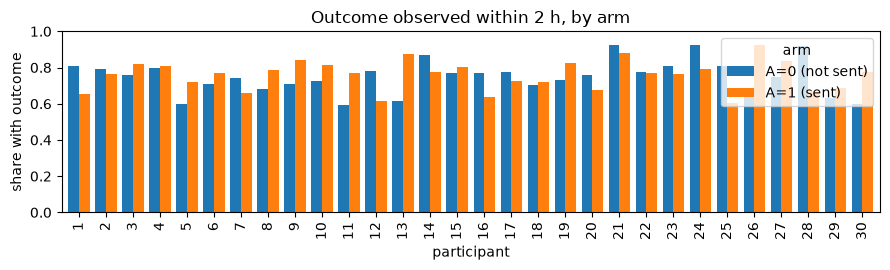

In [9]:
def outcome_missingness(dp):
    a = dp[dp["available"]].assign(arm=lambda d: d["A"].map({1.0: "A=1 (sent)", 0.0: "A=0 (not sent)"}),
                                   has_y=lambda d: d["y"].notna())
    by_arm = a.groupby("arm").agg(points=("has_y", "size"), with_outcome=("has_y", "sum"), rate=("has_y", "mean"))
    by_user = a.pivot_table(index="user_id", columns="arm", values="has_y", aggfunc="mean")
    return by_arm, by_user


by_arm, by_user = outcome_missingness(dp)
display(by_arm)
fig, ax = plt.subplots(figsize=(9, 2.8))
by_user.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("share with outcome"); ax.set_xlabel("participant"); ax.set_ylim(0, 1)
ax.set_title("Outcome observed within 2 h, by arm")
plt.tight_layout(); plt.show()

## 5. The WCLS estimator

WCLS fits one weighted regression on the available rows:

$$
Y_{t+1} = \underbrace{\alpha_0 + \alpha_1\,\text{prior valence} + \alpha_2\,\text{prior stress} + \dots}_{\text{controls } g(H)\text{: absorb noise, allowed to be wrong}} \;+\; \underbrace{(A_t - \tilde p)\,\big(\beta_0 + \beta_1 S_t\big)}_{\text{the causal effect}}
\qquad
W_t = \Big(\tfrac{\tilde p}{p_t}\Big)^{A_t}\Big(\tfrac{1-\tilde p}{1-p_t}\Big)^{1-A_t}
$$

It has three ingredients.

### Ingredient 1: centering (the "C")

The treatment enters as $A - \tilde p$, not $A$: a sent moment gets $+0.5$ and an unsent one $-0.5$. For any
history $H$, the weighted, centered treatment averages exactly zero:

$$
\mathbb{E}[\,W(A-\tilde p)\mid H\,] = p\cdot\tfrac{\tilde p}{p}(1-\tilde p) + (1-p)\cdot\tfrac{1-\tilde p}{1-p}(0-\tilde p) = 0 .
$$

A column with zero mean at every history is **uncorrelated with every function of the history**. Whatever
the control part gets wrong (a forgotten time-of-day pattern, a non-linear prior-mood effect) cannot leak
into $\beta$. It only widens the confidence interval.

### Ingredient 2: weighting (the "W")

$p_t$ is the probability the coin actually used; $\tilde p$ is the mean of the logged $p$. The weight
reshapes the data so it looks as if every moment had been randomized at $\tilde p$. If $p$ were 0.3 in the
morning and 0.6 in the afternoon, sends would pile up in the (happier) afternoon and look good for that
reason alone. The weights undo that. **In REACT today $p \equiv 0.5$, so every weight is 1.** The machinery
is there for a mid-season change to `JITAI_RANDOMIZATION_PROBABILITY`.

The table below checks Ingredients 1 and 2 on the loaded data. Within each hour band, the raw treatment
`A` averages about 0.5, which is its probability. The weighted, centered treatment averages about 0, up to sampling noise
(the late-evening bin has only ~70 rows). That is what makes it orthogonal to hour, and to everything else
in the history.

In [10]:
av = dp[dp["available"]].copy()
p_tilde_demo = av["p"].mean()
av["W"] = np.where(av["A"] == 1, p_tilde_demo / av["p"], (1 - p_tilde_demo) / (1 - av["p"]))
av["centered"] = av["W"] * (av["A"] - p_tilde_demo)
av["hour_bin"] = pd.cut(av["hour"], [8, 11, 14, 17, 20, 23])
grouped = av.groupby("hour_bin", observed=True)
pd.DataFrame({
    "mean(A): uncentered treatment": grouped["A"].mean(),
    "mean(W·(A − p̃)): WCLS treatment": grouped["centered"].mean(),
    "rows": grouped.size(),
}).round(3)

,mean(A): uncentered treatment,mean(W·(A − p̃)): WCLS treatment,rows
hour_bin,,,
"(8, 11]",0.514,0.014,329
"(11, 14]",0.549,0.049,503
"(14, 17]",0.524,0.024,391
"(17, 20]",0.525,0.025,444
"(20, 23]",0.573,0.073,82


### Ingredient 3: working independence plus a small-sample sandwich

The point estimate treats every row as independent. The within-person correlation is handled in the
**standard error**: a cluster-robust *sandwich* that treats each participant as one unit, however many rows
they contribute:

$$
\widehat{\text{Var}}(\hat\theta) = B^{-1} \Big[\sum_i X_i^\top W_i (I - H_{ii})^{-1} r_i r_i^\top (I - H_{ii})^{-\top} W_i X_i\Big] B^{-1},
\qquad B = X^\top W X,\quad H_{ii} = X_i B^{-1} X_i^\top W_i .
$$

The $(I - H_{ii})^{-1}$ factor is the **Mancl–DeRouen** correction. It inflates each person's residuals by
how much that person pulled the fit toward themselves. Inference uses a **$t$ distribution with
df $= n_{\text{participants}} - \dim\alpha - \dim\beta$**. Both matter with 5–35 people: the plain
sandwich is too optimistic there.

In the code below, `_design` builds $X = [\,G \mid (A-\tilde p)F\,]$ with $G = [1, \text{controls}, \text{moderators}]$
and $F = [1, \text{moderators}]$. `fit_wcls` then does the weighted solve, the per-participant sandwich,
and the $t$ inference. `moderator_main_effects=False` exists only to reproduce a common mistake in §8.

In [11]:
DEFAULT_CONTROLS = ("prior_valence", "prior_stress", "hour_c", "day_c")


@dataclass
class FitResult:
    method: str
    label: str
    names: list
    beta: np.ndarray
    se: np.ndarray
    df: int
    n_participants: int
    n_points: int
    extra: dict = field(default_factory=dict)

    def table(self, level=0.95):
        crit = st.t.ppf(0.5 + level / 2, self.df) if self.df > 0 else np.nan
        t = self.beta / self.se
        return pd.DataFrame({
            "method": self.method, "model": self.label, "term": self.names, "estimate": self.beta, "se": self.se,
            "df": self.df, "p_value": 2 * st.t.sf(np.abs(t), self.df) if self.df > 0 else np.nan,
            "ci_low": self.beta - crit * self.se, "ci_high": self.beta + crit * self.se,
            "n_participants": self.n_participants, "n_points": self.n_points,
        })


def analysis_rows(dp, outcome, controls, moderators, cluster="user_id"):
    needed = list(dict.fromkeys([outcome, "A", "p", cluster, *controls, *moderators]))
    return dp[dp["available"]].dropna(subset=needed).sort_values([cluster, "anchor"])


def _g_columns(controls, moderators, moderator_main_effects):
    return list(dict.fromkeys([*controls, *(moderators if moderator_main_effects else ())]))


def _term_names(moderators):
    return ["A"] + [f"A × {m}" for m in moderators]


def _design(d, controls, moderators, p_tilde, moderator_main_effects=True):
    g_cols = _g_columns(controls, moderators, moderator_main_effects)
    G = np.column_stack([np.ones(len(d)), *(d[c].to_numpy(float) for c in g_cols)])
    F = np.column_stack([np.ones(len(d)), *(d[m].to_numpy(float) for m in moderators)])
    X = np.hstack([G, (d["A"].to_numpy(float) - p_tilde)[:, None] * F])
    return X, G.shape[1], F.shape[1]


def fit_wcls(dp, outcome="y", controls=DEFAULT_CONTROLS, moderators=(), cluster="user_id", p_tilde=None,
             label=None, small_sample=True, moderator_main_effects=True):
    d = analysis_rows(dp, outcome, controls, moderators, cluster)
    p_tilde = float(d["p"].mean()) if p_tilde is None else float(p_tilde)
    A, p = d["A"].to_numpy(float), d["p"].to_numpy(float)
    w = np.where(A == 1, p_tilde / p, (1 - p_tilde) / (1 - p))
    X, q, k = _design(d, controls, moderators, p_tilde, moderator_main_effects)
    y = d[outcome].to_numpy(float)

    B = X.T @ (w[:, None] * X)
    B_inv = np.linalg.inv(B)
    theta = B_inv @ (X.T @ (w * y))
    r = y - X @ theta

    meat = np.zeros_like(B)
    groups = d[cluster].to_numpy()
    bounds = np.flatnonzero(np.r_[True, groups[1:] != groups[:-1], True])
    for s, e in zip(bounds[:-1], bounds[1:]):
        Xi, wi, ri = X[s:e], w[s:e], r[s:e]
        if small_sample:
            H = (Xi @ B_inv @ Xi.T) * wi[None, :]
            ri = np.linalg.solve(np.eye(e - s) - H, ri)
        u = Xi.T @ (wi * ri)
        meat += np.outer(u, u)
    V = B_inv @ meat @ B_inv

    n = len(bounds) - 1
    return FitResult(method="WCLS", label=label or ("marginal" if not moderators else " + ".join(moderators)),
                     names=_term_names(moderators), beta=theta[q:], se=np.sqrt(np.diag(V)[q:]),
                     df=n - q - k, n_participants=n, n_points=len(d))

## 6. The baseline: GEE

**Generalized estimating equations** are the standard tool for repeated measures, and most analysts would
fit this:

```
y ~ A + prior_valence + prior_stress + hour_c + day_c      (+ A:moderator)
    grouped by participant, working correlation = independence | exchangeable | AR(1)
```

That is **uncentered, unweighted** $A$, which is how GEE is almost always used. `fit_gee` uses statsmodels
`GEE` with the same rows, controls and moderators as WCLS, and the same Mancl–DeRouen (`bias_reduced`)
standard errors, so any difference comes from the estimator, not from the data or the variance formula.

The three working correlations make different assumptions:

| Working correlation | Assumption | Concern in an MRT |
|---|---|---|
| **Independence** | Rows are uncorrelated when estimating; the sandwich fixes the SEs | Same as WCLS except for centering and weighting. It inherits problems A and B below. |
| **Exchangeable** | Every pair of rows from one person is equally correlated | Uses a person's *other* rows, including later ones, to estimate each row. This is valid only if the outcome at $t$ is unrelated to covariates at other times (Pepe & Anderson, 1994), and REACT breaks that by construction, because today's outcome is tomorrow's `prior_valence`. |
| **AR(1)** | Nearby rows are more correlated | Same concern as exchangeable. |

What can go wrong for a GEE baseline:

- **A. No centering.** In `A:hour` without an `hour` main effect, the column `A × hour` is `hour` on sent
  moments and 0 otherwise, so it correlates with `hour`. It then reports "evenings are happier" as "prompts
  work better in the evening."
- **B. No weighting.** If $p$ varies with something that also affects the outcome, sends cluster where
  outcomes are already better, and the estimate is confounded **by the design itself**.
- **C. Non-independence working correlation** uses future rows that past treatment has influenced (the
  feedback loop).

§8 tests all three on data with a known truth.

In [12]:
GEE_STRUCTURES = {
    "GEE independence": Independence,
    "GEE exchangeable": Exchangeable,
    "GEE AR(1)": lambda: Autoregressive(grid=True),
}


def fit_gee(dp, structure="GEE exchangeable", outcome="y", controls=DEFAULT_CONTROLS, moderators=(),
            cluster="user_id", label=None, moderator_main_effects=True):
    d = analysis_rows(dp, outcome, controls, moderators, cluster)
    g_cols = _g_columns(controls, moderators, moderator_main_effects)
    A = d["A"].to_numpy(float)
    X = np.column_stack([np.ones(len(d)), *(d[c].to_numpy(float) for c in g_cols), A,
                         *(A * d[m].to_numpy(float) for m in moderators)])
    time = d.groupby(cluster).cumcount().to_numpy()
    model = sm.GEE(d[outcome].to_numpy(float), X, groups=d[cluster].to_numpy(), time=time,
                   cov_struct=GEE_STRUCTURES[structure]())
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = model.fit(cov_type="bias_reduced", maxiter=100)
    q = 1 + len(g_cols)
    n = d[cluster].nunique()
    return FitResult(method=structure, label=label or ("marginal" if not moderators else " + ".join(moderators)),
                     names=_term_names(moderators), beta=np.asarray(fit.params[q:]), se=np.asarray(fit.bse[q:]),
                     df=n - q - (1 + len(moderators)), n_participants=n, n_points=len(d),
                     extra=dict(working_correlation=_first_param(model.cov_struct.dep_params)))


def _first_param(dep_params):
    values = np.ravel(np.asarray(dep_params if dep_params is not None else [], dtype=float))
    return float(values[0]) if values.size else 0.0

## 7. Results

### 7.1 WCLS: overall effect and moderators

The notebook fits four models per outcome: the overall (marginal) effect, and one model each moderated by
hour of day, study day and baseline MSSD. If fewer than 12 participants have outcomes (Phase 1 has 5), it
automatically drops to a single control, prior valence, because every extra parameter costs one of very
few degrees of freedom. More on this in §8.

In [13]:
MODERATOR_SETS = {
    "marginal": (),
    "hour of day": ("hour_c",),
    "study day": ("day_c",),
    "baseline MSSD": ("mssd_c",),
}
METHODS = ["WCLS", *GEE_STRUCTURES]


def fit_method(method, dp, **kw):
    return fit_wcls(dp, **kw) if method == "WCLS" else fit_gee(dp, structure=method, **kw)


def run_models(dp, outcome_label, methods=METHODS, controls=DEFAULT_CONTROLS):
    rows = [fit_method(m, dp, moderators=mods, label=name, controls=controls).table()
            for name, mods in MODERATOR_SETS.items() for m in methods]
    return pd.concat(rows, ignore_index=True).assign(outcome=outcome_label)


CONTROLS = DEFAULT_CONTROLS if N_PARTICIPANTS >= 12 else ("prior_valence",)
print(f"{N_PARTICIPANTS} participants with outcomes -> controls = {CONTROLS}")
results_valence = run_models(dp, "B1_valence", controls=CONTROLS)
results_valence.query("method == 'WCLS'").drop(columns=["method"]).round(4)

30 participants with outcomes -> controls = ('prior_valence', 'prior_stress', 'hour_c', 'day_c')


,model,term,estimate,se,df,p_value,ci_low,ci_high,n_participants,n_points,outcome
0,marginal,A,0.3576,0.0612,24,0.0000,0.2314,0.4839,30,1319,B1_valence
4,hour of day,A,0.3780,0.0595,23,0.0000,0.2550,0.5011,30,1319,B1_valence
5,hour of day,A × hour_c,0.0474,0.0195,23,0.0234,0.0070,0.0879,30,1319,B1_valence
12,study day,A,0.3573,0.0621,23,0.0000,0.2289,0.4857,30,1319,B1_valence
13,study day,A × day_c,-0.0014,0.0077,23,0.8527,-0.0174,0.0145,30,1319,B1_valence
20,baseline MSSD,A,0.3571,0.0620,22,0.0000,0.2286,0.4856,30,1319,B1_valence
21,baseline MSSD,A × mssd_c,-0.1008,0.1891,22,0.5994,-0.4929,0.2914,30,1319,B1_valence


**How to read this table**

- **`A` in the `marginal` row** is the headline: the average change in next-check-in valence (1–7 scale) from
  sending vs. not sending at an available moment. For example, 0.35 means a prompt raises the next valence
  by about a third of a point on average.
- **In a moderated model**, `A` is the effect at the moderator's center (3 pm, mid-study, average MSSD).
  `A × hour_c` is how much the effect changes **per hour later in the day**, `A × day_c` per study day, and
  `A × mssd_c` per unit of baseline MSSD.
- **`ci_low` / `ci_high`** is a 95 % interval from a $t$ distribution with `df` degrees of freedom. `df` is
  the participant count minus the number of parameters. If it is ≤ 0 the model is not estimable, and the
  table shows NaN.
- **A moderator whose CI straddles 0** is no evidence of moderation. It is *not* evidence of no moderation
  either, especially with few participants.

In [14]:
dp_stress = build_decision_points(frames["jitai"], frames["ema"], frames["items"], frames["users"], outcome_item="B2_stress")
dp_stress = add_baseline_mssd(dp_stress, frames["ema"], frames["items"], frames["users"])
if cutover is not None:
    dp_stress = dp_stress[dp_stress["anchor"] >= cutover].reset_index(drop=True)
results_stress = run_models(dp_stress, "B2_stress", controls=CONTROLS)
results_stress.query("method == 'WCLS'").drop(columns=["method"]).round(4)

,model,term,estimate,se,df,p_value,ci_low,ci_high,n_participants,n_points,outcome
0,marginal,A,-0.3036,0.0535,24,0.0000,-0.4140,-0.1932,30,1319,B2_stress
4,hour of day,A,-0.3037,0.0566,23,0.0000,-0.4208,-0.1867,30,1319,B2_stress
5,hour of day,A × hour_c,-0.0003,0.0206,23,0.9902,-0.0428,0.0423,30,1319,B2_stress
12,study day,A,-0.3036,0.0535,23,0.0000,-0.4142,-0.1929,30,1319,B2_stress
13,study day,A × day_c,0.0002,0.0075,23,0.9788,-0.0153,0.0157,30,1319,B2_stress
20,baseline MSSD,A,-0.3024,0.0549,22,0.0000,-0.4162,-0.1887,30,1319,B2_stress
21,baseline MSSD,A × mssd_c,0.0622,0.1595,22,0.7001,-0.2685,0.3930,30,1319,B2_stress


For stress (`B2_stress`, higher = more stressed), a **negative** effect means the prompt reduced stress.

### 7.2 WCLS vs. GEE on the loaded data

Estimate ± SE for every model, method and outcome:

In [15]:
def side_by_side(results):
    wide = results.assign(cell=lambda r: r["estimate"].map("{:+.3f}".format) + " ± " + r["se"].map("{:.3f}".format))
    return wide.pivot_table(index=["outcome", "model", "term"], columns="method", values="cell", aggfunc="first")[METHODS]


side_by_side(pd.concat([results_valence, results_stress]))

method                                         WCLS GEE independence GEE exchangeable       GEE AR(1)
outcome    model         term                                                                        
B1_valence baseline MSSD A           +0.357 ± 0.062   +0.357 ± 0.062   +0.368 ± 0.061  +0.354 ± 0.063
                         A × mssd_c  -0.101 ± 0.189   -0.101 ± 0.189   -0.072 ± 0.205  -0.102 ± 0.217
           hour of day   A           +0.378 ± 0.059   +0.378 ± 0.059   +0.389 ± 0.058  +0.377 ± 0.060
                         A × hour_c  +0.047 ± 0.020   +0.047 ± 0.020   +0.049 ± 0.019  +0.053 ± 0.019
           marginal      A           +0.358 ± 0.061   +0.358 ± 0.061   +0.368 ± 0.059  +0.354 ± 0.062
           study day     A           +0.357 ± 0.062   +0.357 ± 0.062   +0.368 ± 0.060  +0.354 ± 0.063
                         A × day_c   -0.001 ± 0.008   -0.001 ± 0.008   -0.003 ± 0.007  -0.001 ± 0.008
B2_stress  baseline MSSD A           -0.302 ± 0.055   -0.302 ± 0.055   -0.297 ± 0.054  -0.308 ± 0.052
                         A × mssd_c  +0.062 ± 0.159   +0.062 ± 0.159   +0.050 ± 0.154  +0.053 ± 0.136
           hour of day   A           -0.304 ± 0.057   -0.304 ± 0.057   -0.297 ± 0.056  -0.309 ± 0.054
                         A × hour_c  -0.000 ± 0.021   -0.000 ± 0.021   +0.001 ± 0.020  +0.001 ± 0.020
           marginal      A           -0.304 ± 0.054   -0.304 ± 0.054   -0.298 ± 0.053  -0.309 ± 0.051
           study day     A           -0.304 ± 0.053   -0.304 ± 0.053   -0.298 ± 0.053  -0.310 ± 0.051
                         A × day_c   +0.000 ± 0.007   +0.000 ± 0.007   -0.000 ± 0.007  -0.001 ± 0.007

The estimated working correlations show *how much* the exchangeable and AR(1) fits lean on a person's
other rows. Values near 0 mean they behave almost like independence. This comes up again in §8c,
scenario 4.

In [16]:
pd.DataFrame([dict(outcome=label, structure=s,
                   estimated_working_correlation=fit_gee(frame, s, controls=CONTROLS).extra["working_correlation"])
              for label, frame in (("B1_valence", dp), ("B2_stress", dp_stress))
              for s in ("GEE exchangeable", "GEE AR(1)")]).round(3)

,outcome,structure,estimated_working_correlation
0,B1_valence,GEE exchangeable,0.056
1,B1_valence,GEE AR(1),0.076
2,B2_stress,GEE exchangeable,0.056
3,B2_stress,GEE AR(1),0.071


On the default synthetic data ($p = 0.5$, and the moderators' main effects are included as controls), the
four methods agree closely:

- **GEE independence equals WCLS to every printed digit.** With constant $p$, the weights are 1, and when
  the controls include every moderator, centering changes only the intercept.
- **Exchangeable and AR(1)** differ only slightly.

Agreement here does **not** mean the methods are interchangeable. §8 shows the conditions under which they
come apart. Those are conditions REACT can easily drift into: a changed randomization probability, or a
moderator model written without its main effect.

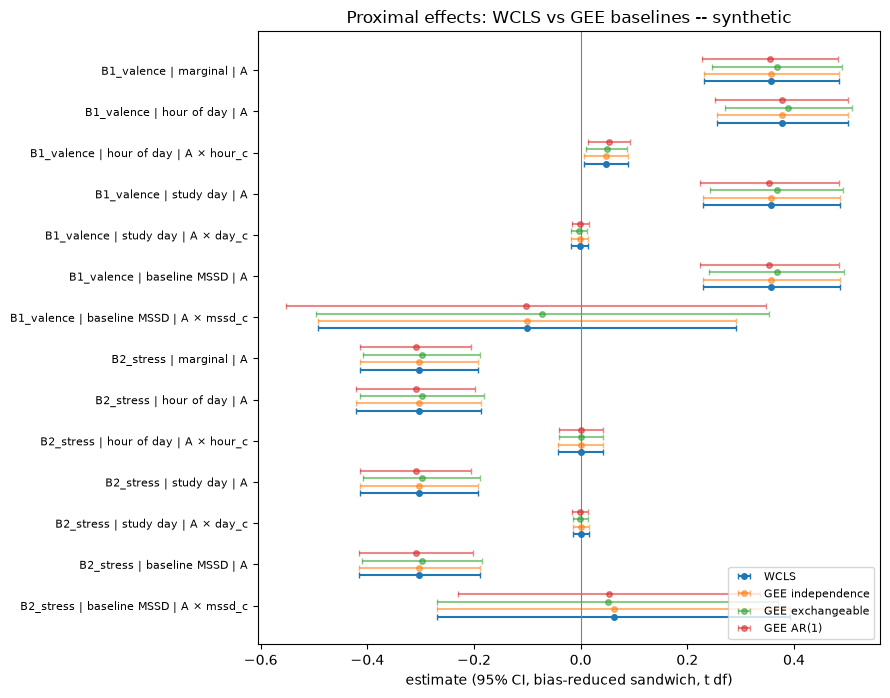

In [17]:
all_res = pd.concat([results_valence, results_stress], ignore_index=True)
all_res["row"] = all_res["outcome"] + " | " + all_res["model"] + " | " + all_res["term"]
rows = all_res["row"].drop_duplicates().tolist()
fig, ax = plt.subplots(figsize=(9, 0.42 * len(rows) + 1.2))
offsets = dict(zip(METHODS, np.linspace(-0.27, 0.27, len(METHODS))))
for method, g in all_res.groupby("method", sort=False):
    yy = np.array([len(rows) - 1 - rows.index(r) for r in g["row"]]) + offsets[method]
    ax.errorbar(g["estimate"], yy, xerr=[g["estimate"] - g["ci_low"], g["ci_high"] - g["estimate"]],
                fmt="o", ms=4, capsize=2, label=method, alpha=1 if method == "WCLS" else 0.55)
ax.axvline(0, color="grey", lw=0.8)
ax.set_yticks(np.arange(len(rows))[::-1]); ax.set_yticklabels(rows, fontsize=8)
ax.set_xlabel("estimate (95% CI, bias-reduced sandwich, t df)")
ax.set_title(f"Proximal effects: WCLS vs GEE baselines -- {DATA_SOURCE}")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## 8. Evaluating the implementation

Four questions, in increasing order of strength:

1. **Is the arithmetic right?** Compare with statsmodels (8a).
2. **Does one dataset land near the truth?** (8b)
3. **Across hundreds of datasets, are the estimates unbiased and do the 95 % intervals cover 95 % of the
   time?** Compare WCLS with the GEE baselines under four scenarios (8c).
4. **What happens with Phase-1-sized samples?** (8d)

### 8a. Arithmetic: WCLS equals WLS on the centered design

WCLS is a weighted least squares fit on the centered design, so statsmodels `WLS` must return **identical**
coefficients. The cell asserts this for every model. The SE columns show what the small-sample correction
does: Mancl–DeRouen is always wider than the uncorrected sandwich and statsmodels' CR1. The difference is
about 5 % for most terms and about 15 % for the baseline-MSSD interaction. That moderator varies only
*between* people, so it has effectively 30 observations, not 600, and each person's leverage is larger.

In [18]:
def statsmodels_check(dp, moderators):
    d = analysis_rows(dp, "y", DEFAULT_CONTROLS, moderators)
    p_tilde = d["p"].mean()
    X, q, _ = _design(d, DEFAULT_CONTROLS, moderators, p_tilde)
    w = np.where(d["A"] == 1, p_tilde / d["p"], (1 - p_tilde) / (1 - d["p"]))
    fit = sm.WLS(d["y"].to_numpy(float), X, weights=w).fit(cov_type="cluster", cov_kwds={"groups": d["user_id"].to_numpy()})
    ours = fit_wcls(dp, moderators=moderators)
    ours_raw = fit_wcls(dp, moderators=moderators, small_sample=False)
    assert np.allclose(fit.params[q:], ours.beta, atol=1e-10), "point estimates disagree with statsmodels WLS"
    return pd.DataFrame({"term": ours.names, "beta (ours)": ours.beta, "beta (statsmodels WLS)": fit.params[q:],
                         "se Mancl-DeRouen": ours.se, "se uncorrected (ours)": ours_raw.se,
                         "se CR1 (statsmodels)": fit.bse[q:]})


pd.concat([statsmodels_check(dp, mods).assign(model=name) for name, mods in MODERATOR_SETS.items()], ignore_index=True).round(5)

,term,beta (ours),beta (statsmodels WLS),se Mancl-DeRouen,se uncorrected (ours),se CR1 (statsmodels),model
0,A,0.35765,0.35765,0.06119,0.05884,0.05996,marginal
1,A,0.37805,0.37805,0.05947,0.05719,0.05830,hour of day
2,A × hour_c,0.04745,0.04745,0.01955,0.01884,0.01921,hour of day
3,A,0.35732,0.35732,0.06206,0.05948,0.06064,study day
4,A × day_c,-0.00144,-0.00144,0.00769,0.00728,0.00743,study day
5,A,0.35710,0.35710,0.06196,0.05789,0.05903,baseline MSSD
6,A × mssd_c,-0.10077,-0.10077,0.18909,0.14144,0.14424,baseline MSSD


### 8b. One dataset against the truth

The truth is the average potential-outcome difference, `round(L + δ) − round(L)`, over the rows that
entered the fit. The moderated truth is its regression on the centered moderator. **One dataset is one
draw**: an estimate 1–2 SE from the truth is normal. The question is whether the 95 % interval contains the
truth. 8c answers that properly.

In [19]:
def truth_values(dp, truth, outcome_col, controls=DEFAULT_CONTROLS, moderators=()):
    d = analysis_rows(dp, "y", controls, moderators).merge(truth, on="jitai_log_id", how="left")
    marg = d[outcome_col].mean()
    slope, intercept = np.polyfit(d["hour_c"], d[outcome_col], 1)
    return dict(marginal=marg, at_15h=intercept, per_hour=slope)


if DATA_SOURCE == "synthetic":
    tv = truth_values(dp, truth, "true_dv")
    ts = truth_values(dp_stress, truth, "true_ds")
    picks = [("valence, marginal", results_valence.query("model == 'marginal'"), tv["marginal"]),
             ("valence, A × hour_c", results_valence.query("model == 'hour of day' and term != 'A'"), tv["per_hour"]),
             ("stress, marginal", results_stress.query("model == 'marginal'"), ts["marginal"])]
    rec = []
    for label, sub, target in picks:
        for _, r in sub.iterrows():
            rec.append(dict(quantity=label, method=r["method"], estimate=r["estimate"], ci_low=r["ci_low"],
                            ci_high=r["ci_high"], truth=target, truth_in_ci=r["ci_low"] <= target <= r["ci_high"]))
    display(pd.DataFrame(rec).set_index(["quantity", "method"]).round(3))

estimate  ci_low  ci_high  truth  truth_in_ci
quantity            method                                                         
valence, marginal   WCLS                 0.358   0.231    0.484  0.356         True
                    GEE independence     0.358   0.231    0.484  0.356         True
                    GEE exchangeable     0.368   0.246    0.491  0.356         True
                    GEE AR(1)            0.354   0.227    0.482  0.356         True
valence, A × hour_c WCLS                 0.047   0.007    0.088  0.056         True
                    GEE independence     0.047   0.007    0.088  0.056         True
                    GEE exchangeable     0.049   0.009    0.088  0.056         True
                    GEE AR(1)            0.053   0.014    0.092  0.056         True
stress, marginal    WCLS                -0.304  -0.414   -0.193 -0.294         True
                    GEE independence    -0.304  -0.414   -0.193 -0.294         True
                    GEE exchangeable    -0.298  -0.407   -0.189 -0.294         True
                    GEE AR(1)           -0.309  -0.414   -0.205 -0.294         True

### 8c. Monte Carlo: WCLS vs. GEE across five scenarios

The whole pipeline (simulator → builder → estimator) runs `MC_REPS` times with 30 participants. For each
scenario and method the table reports:

- **bias**: average estimate − truth. It should be ≈ 0.
- **emp_sd**: how much estimates vary across datasets. Smaller is more precise.
- **rmse**: bias and variance combined.
- **coverage**: the share of 95 % intervals that contain the truth. It should be ≈ 0.95.

**✓** means |bias| < 0.05 and coverage within 0.92–0.98, the Monte Carlo noise band for 200 repetitions.

| Scenario | Set-up | Tests |
|---|---|---|
| **1** production-like | $p = 0.5$, full controls; marginal and `A × hour` | The everyday case |
| **2** time-varying $p$ | $p$ = 0.3 before noon, 0.6 after; evenings happier; `hour` not among the controls | Weighting (problem B) |
| **3** missing main effect | `A × hour` model without an `hour` control; evenings happier | Centering (problem A) |
| **3b** same, legacy design | Scenario 3 on data from the pre-fix outcome design (§9) | What arm-dependent missingness does to centering |
| **4** feedback-loop stress test | Effect larger when prior mood is low; carryover ×4; `A × prior valence`, no controls | Working correlation (problem C) |

In [20]:
def p_by_hour(hour):
    return 0.3 if hour < 12 else 0.6


SCENARIOS = {
    "1 production-like": dict(sim=dict(), controls=DEFAULT_CONTROLS, moderators=(), main=True),
    "1 production-like, A × hour": dict(sim=dict(), controls=DEFAULT_CONTROLS, moderators=("hour_c",), main=True),
    "2 time-varying p, hour not controlled": dict(sim=dict(p_fn=p_by_hour), controls=("prior_valence", "prior_stress", "day_c"),
                                                   moderators=(), main=True),
    "3 A × hour without hour main effect": dict(sim=dict(), controls=("prior_valence", "prior_stress", "day_c"),
                                                 moderators=("hour_c",), main=False),
    "3b same, legacy post-prompt-only outcome design": dict(sim=dict(design="legacy"), outcome="next_scheduled",
                                                             controls=("prior_valence", "prior_stress", "day_c"),
                                                             moderators=("hour_c",), main=False),
    "4 feedback-loop stress test, A × prior valence": dict(sim=dict(beta_prior=0.15, carryover=2.0), controls=(),
                                                            moderators=("prior_c",), main=True),
}


def truth_targets(d, tr, sc):
    rows = analysis_rows(d, "y", sc["controls"], sc["moderators"]).merge(tr, on="jitai_log_id", how="left")
    if not sc["moderators"]:
        return [rows["true_dv"].mean()]
    slope, intercept = np.polyfit(rows[sc["moderators"][0]], rows["true_dv"], 1)
    return [intercept, slope]


def monte_carlo(reps, n_users=30, seed0=10_000, scenarios=SCENARIOS, methods=METHODS):
    rows = []
    for r in range(reps):
        cache = {}
        for name, sc in scenarios.items():
            outcome = sc.get("outcome", "linked")
            key = (tuple(sorted(sc["sim"].items(), key=lambda kv: kv[0])), outcome)
            if key not in cache:
                fr, tr = simulate_cohort(n_users=n_users, seed=seed0 + r, **sc["sim"])
                d = build_decision_points(fr["jitai"], fr["ema"], fr["items"], fr["users"], outcome_definition=outcome)
                d["prior_c"] = d["prior_valence"] - 4
                cache[key] = (d, tr)
            d, tr = cache[key]
            targets = truth_targets(d, tr, sc)
            for method in methods:
                tab = fit_method(method, d, controls=sc["controls"], moderators=sc["moderators"],
                                 moderator_main_effects=sc["main"]).table()
                for i, target in enumerate(targets):
                    rows.append(dict(scenario=name, method=method, term=tab["term"].iloc[i], rep=r, truth=target,
                                     est=tab["estimate"].iloc[i],
                                     covered=tab["ci_low"].iloc[i] <= target <= tab["ci_high"].iloc[i]))
    out = pd.DataFrame(rows)
    out["err"] = out["est"] - out["truth"]
    summary = (out.groupby(["scenario", "term", "method"], sort=False)
                  .agg(mean_truth=("truth", "mean"), bias=("err", "mean"), emp_sd=("est", "std"),
                       rmse=("err", lambda e: np.sqrt((e ** 2).mean())), coverage=("covered", "mean"))
                  .reset_index())
    summary["verdict"] = np.where((summary["bias"].abs() < 0.05) & summary["coverage"].between(0.92, 0.98), "✓", "✗")
    return summary


if DATA_SOURCE == "synthetic" and RUN_MONTE_CARLO:
    mc = monte_carlo(MC_REPS)
    display(mc.round(3))

,scenario,term,method,mean_truth,bias,emp_sd,rmse,coverage,verdict
0,1 production-like,A,WCLS,0.365,-0.004,0.061,0.060,0.970,✓
1,1 production-like,A,GEE independence,0.365,-0.004,0.061,0.060,0.970,✓
2,1 production-like,A,GEE exchangeable,0.365,-0.004,0.060,0.059,0.965,✓
3,1 production-like,A,GEE AR(1),0.365,-0.004,0.061,0.060,0.970,✓
4,"1 production-like, A × hour",A,WCLS,0.387,-0.004,0.061,0.059,0.970,✓
5,"1 production-like, A × hour",A × hour_c,WCLS,0.048,-0.000,0.017,0.017,0.960,✓
6,"1 production-like, A × hour",A,GEE independence,0.387,-0.004,0.061,0.059,0.970,✓
7,"1 production-like, A × hour",A × hour_c,GEE independence,0.048,-0.000,0.017,0.017,0.960,✓
8,"1 production-like, A × hour",A,GEE exchangeable,0.387,-0.004,0.060,0.059,0.965,✓
9,"1 production-like, A × hour",A × hour_c,GEE exchangeable,0.048,-0.000,0.017,0.016,0.965,✓


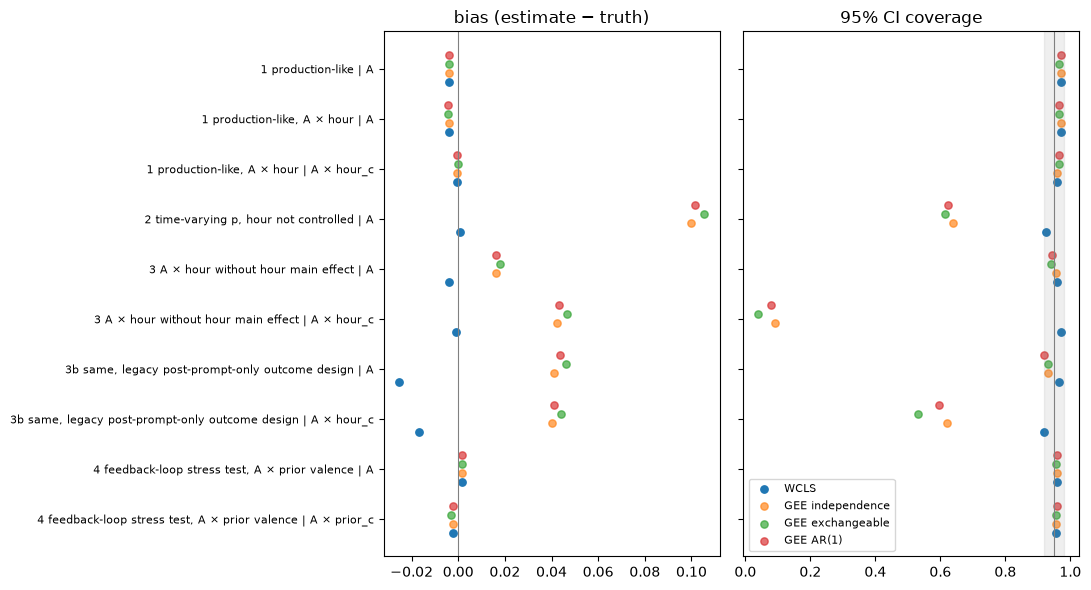

In [21]:
if DATA_SOURCE == "synthetic" and RUN_MONTE_CARLO:
    fig, axes = plt.subplots(1, 2, figsize=(11, 0.45 * mc[["scenario", "term"]].drop_duplicates().shape[0] + 1.5), sharey=True)
    labels = (mc["scenario"] + " | " + mc["term"]).drop_duplicates().tolist()
    for ax, col, ref, title in [(axes[0], "bias", 0.0, "bias (estimate − truth)"),
                                (axes[1], "coverage", 0.95, "95% CI coverage")]:
        for method, g in mc.groupby("method", sort=False):
            yy = np.array([len(labels) - 1 - labels.index(l) for l in g["scenario"] + " | " + g["term"]]) + offsets[method]
            ax.scatter(g[col], yy, label=method, s=28, alpha=1 if method == "WCLS" else 0.65)
        ax.axvline(ref, color="grey", lw=0.8)
        ax.set_title(title)
    axes[1].axvspan(0.92, 0.98, color="grey", alpha=0.12)
    axes[0].set_yticks(np.arange(len(labels))[::-1]); axes[0].set_yticklabels(labels, fontsize=8)
    axes[1].legend(fontsize=8, loc="lower left")
    plt.tight_layout(); plt.show()

**What the simulation shows**

- **Scenario 1: everyone passes.** With constant $p$ and a complete control set, the GEE baselines are
  as good as WCLS: bias ≤ 0.004 and coverage 0.96–0.97. This is expected, and it is why §7's numbers agree.
- **Scenario 2: all three GEEs fail and WCLS passes.** With a time-varying $p$, sends pile up in the happier
  afternoon. Uncentered, unweighted GEE credits the prompt with part of that afternoon lift: the bias is about
  +0.10 on a true effect of 0.37 (over a quarter too large), and coverage falls to 62–64 %. The WCLS weights
  remove it (bias 0.001, coverage 0.925). **The working correlation doesn't help, because the problem is
  confounding, not correlation.**
- **Scenario 3: all three GEEs report spurious moderation; WCLS doesn't.** Without the `hour` main effect,
  the GEE `A × hour_c` coefficient absorbs the time-of-day pattern. It comes out about 0.09 against a true
  0.05, nearly double, and its intervals cover the truth only 4–9 % of the time. The centered WCLS column is
  orthogonal to `hour`, so the omission costs it nothing measurable here (bias −0.001, coverage 0.97).
- **Scenario 3b: the same model on legacy-design data.** Under the old design, outcomes were missing more
  often after a send, so among rows that have an outcome, P(A = 1) is about 0.45, not 0.50. Centering is exact
  only over *all* available rows, so the centered column becomes slightly correlated with `hour` among the
  observed ones, and the omitted time-of-day effect leaks in. The predicted leak,
  (0.45 − 0.50) / 0.25 × 0.08 ≈ −0.017, matches the observed WCLS bias exactly. This is the concrete cost of
  the pre-fix design, and the reason §4.2's by-arm table matters on live data. **Always include each
  moderator's main effect in the controls** (the default), which makes the estimate robust to exactly this.
- **Scenario 4: the feedback loop does *not* bias exchangeable or AR(1) GEE measurably here.** This
  contradicts a common warning (and `wcls-explainer.md` §6C), so it deserves an honest note. The
  Pepe–Anderson condition *is* violated, because today's outcome is tomorrow's `prior_valence`. But $A$ is
  randomized with a known probability, and the estimated working correlations are small (≈ 0.06–0.08 in
  §7.2). So the bias is negligible in REACT-like data. The risk grows with strong within-person correlation,
  time-varying $p$, or non-linear models. WCLS avoids having to argue the case at all, but in REACT the
  stronger reasons to prefer it are scenarios 2 and 3.

**Bottom line for REACT.** GEE fails when the randomization probability varies or when the moderator
specification is incomplete. The failure isn't in the correlation structure. It is that GEE uses $A$
instead of $W(A - \tilde p)$. WCLS gives the same answer as GEE when everything is specified well, and the
right answer when something isn't.

### 8d. Small samples: what Phase 1 can support

The same check at **8 participants**. With the full control set, df = 8 − 5 − 1 = 2, so the $t$
critical value is about 4.3. The intervals are valid but so wide that they over-cover. With prior valence
as the only control, df = 5, and coverage returns to roughly nominal.

**Rule of thumb:** keep total parameters well below the participant count. That is why §7 switches to a
single control below 12 participants. With 5 participants (Phase 1), only the marginal model with one
control is estimable (df = 2). Treat it as descriptive.

In [22]:
if DATA_SOURCE == "synthetic" and RUN_MONTE_CARLO:
    small = {
        "n=8, full controls (df = 8 − 5 − 1 = 2)": dict(sim=dict(), controls=DEFAULT_CONTROLS, moderators=(), main=True),
        "n=8, prior valence only (df = 8 − 2 − 1 = 5)": dict(sim=dict(), controls=("prior_valence",), moderators=(), main=True),
    }
    display(monte_carlo(MC_REPS, n_users=8, seed0=20_000, scenarios=small, methods=["WCLS", "GEE independence"]).round(3))

,scenario,term,method,mean_truth,bias,emp_sd,rmse,coverage,verdict
0,"n=8, full controls (df = 8 − 5 − 1 = 2)",A,WCLS,0.367,-0.002,0.113,0.113,0.995,✗
1,"n=8, full controls (df = 8 − 5 − 1 = 2)",A,GEE independence,0.367,-0.002,0.113,0.113,0.995,✗
2,"n=8, prior valence only (df = 8 − 2 − 1 = 5)",A,WCLS,0.367,-0.002,0.115,0.113,0.970,✓
3,"n=8, prior valence only (df = 8 − 2 − 1 = 5)",A,GEE independence,0.367,-0.002,0.115,0.113,0.970,✓


### 8e. Power at the planned sample size

**Power** is the chance that the primary test detects a prompt effect that really exists. The **minimum
detectable effect (MDE)** is the smallest standardized effect (in residual-SD units) that the study detects
80 % of the time at α = 0.05. Paper B §3.4 reports MDEs for the planned enrollment:
- a phased 5 + 40 + 40 rollout, analyzed as N = 80;
- availability 0.2;
- 28 randomized days × 6 decision points.

It computes them from the closed form of Liao et al. (2016) for the one-degree-of-freedom marginal test:

$$\lambda = N\,d^2\,p(1-p)\sum_t \mathbb{E}[I_t],\qquad \text{power} = \Pr\big(F_{1,\,N-q-1}(\lambda) > F^{crit}\big).$$

The cell below recomputes that table and **asserts it matches the paper to three decimals**, so the two
cannot drift apart.

In [23]:
RANDOMIZED_DAYS = STUDY_DAYS - RUN_IN_DAYS
DECISIONS_PER_DAY = 6
POWER_N = 80
POWER_AVAILABILITY = 0.2


def power_closed_form(d, n, available_per_person, p=RANDOMIZATION_P_DEFAULT, q=2, alpha=0.05):
    lam = n * d ** 2 * p * (1 - p) * available_per_person
    df2 = n - q - 1
    return 1 - st.ncf.cdf(st.f.ppf(1 - alpha, 1, df2), 1, df2, lam)


from scipy.optimize import brentq


def mde_closed_form(n, available_per_person, target=0.8, **kw):
    return brentq(lambda d: power_closed_form(d, n, available_per_person, **kw) - target, 1e-4, 3)


POWER_SCENARIOS = pd.DataFrame([
    ("protocol's assumption: availability 0.6", 80, 0.6, 1.00, 1.00),
    ("as built: availability 0.2", 80, 0.2, 1.00, 1.00),
    ("+ 75 % check-in completion", 80, 0.2, 0.75, 1.00),
    ("+ 75 % of outcome check-ins answered", 80, 0.2, 0.75, 0.75),
    ("same, 70 retained", 70, 0.2, 0.75, 0.75),
], columns=["scenario", "n", "availability", "completion", "response"])
POWER_SCENARIOS["available_per_person"] = (RANDOMIZED_DAYS * DECISIONS_PER_DAY * POWER_SCENARIOS["availability"]
                                           * POWER_SCENARIOS["completion"] * POWER_SCENARIOS["response"])
POWER_SCENARIOS["mde_closed_form"] = [mde_closed_form(n, t) for n, t in
                                      zip(POWER_SCENARIOS["n"], POWER_SCENARIOS["available_per_person"])]
PAPER_MDES = [0.063, 0.109, 0.126, 0.146, 0.156]
assert np.allclose(POWER_SCENARIOS["mde_closed_form"].round(3), PAPER_MDES), "notebook and paper §3.4 disagree"
POWER_SCENARIOS.round(3)

,scenario,n,availability,completion,response,available_per_person,mde_closed_form
0,protocol's assumption: availability 0.6,80,0.6,1.00,1.00,100.8,0.063
1,as built: availability 0.2,80,0.2,1.00,1.00,33.6,0.109
2,+ 75 % check-in completion,80,0.2,0.75,1.00,25.2,0.126
3,+ 75 % of outcome check-ins answered,80,0.2,0.75,0.75,18.9,0.146
4,"same, 70 retained",70,0.2,0.75,0.75,18.9,0.156


**Check 1: does the closed form survive the estimator we actually use?** The closed form assumes that every
participant has the same number of available decision points, that there is no between-person variation,
that errors are independent, and a plain F test. Each simulated dataset below breaks all four assumptions:
- the number of available points is random per person;
- every person has their own intercept (SD 0.5);
- errors are AR(1) within person (ρ = 0.3), with total residual SD 1, so the effect β *is* the
  standardized d;
- the fit uses `fit_wcls` with the Mancl–DeRouen t test.

For each scenario the simulation records the rejection rate **at the closed-form MDE**, which should be
≈ 0.80, and **at zero effect**, which should be ≈ 0.05. Each uses 1,000 datasets.

In [24]:
def simulate_power_dataset(rng, n, availability, completion, response, beta, rho=0.3, person_sd=0.5):
    slots = RANDOMIZED_DAYS * DECISIONS_PER_DAY
    within_sd = np.sqrt(1 - person_sd ** 2)
    e = np.empty((n, slots))
    e[:, 0] = rng.normal(0, 1, n)
    shocks = rng.normal(0, np.sqrt(1 - rho ** 2), (n, slots))
    for t in range(1, slots):
        e[:, t] = rho * e[:, t - 1] + shocks[:, t]
    u = rng.normal(0, person_sd, (n, 1))
    completed = rng.random((n, slots)) < completion
    available = completed & (rng.random((n, slots)) < availability)
    A = (rng.random((n, slots)) < RANDOMIZATION_P_DEFAULT).astype(float)
    y = u + within_sd * e + beta * A
    observed = rng.random((n, slots)) < response
    keep = completed
    users, times = np.nonzero(keep)
    frame = pd.DataFrame({
        "user_id": users, "anchor": times, "available": available[keep],
        "A": np.where(available[keep], A[keep], np.nan), "p": RANDOMIZATION_P_DEFAULT,
        "y": np.where(observed[keep], y[keep], np.nan),
    })
    return frame


def simulate_power(scenario, beta, reps, seed):
    rng = np.random.default_rng(seed)
    hits = 0
    for _ in range(reps):
        d = simulate_power_dataset(rng, scenario["n"], scenario["availability"], scenario["completion"],
                                   scenario["response"], beta)
        hits += fit_wcls(d, controls=()).table()["p_value"].iloc[0] < 0.05
    return hits / reps


POWER_REPS = 1000
if RUN_MONTE_CARLO:
    rows = []
    for i, sc in POWER_SCENARIOS.iterrows():
        power_at_mde = simulate_power(sc, sc["mde_closed_form"], POWER_REPS, seed=31_000 + i)
        type_one = simulate_power(sc, 0.0, POWER_REPS, seed=41_000 + i)
        rows.append(dict(scenario=sc["scenario"], mde_closed_form=sc["mde_closed_form"],
                         simulated_power_at_mde=power_at_mde, type_one_error=type_one))
    power_check = pd.DataFrame(rows)
    mc_se = np.sqrt(0.8 * 0.2 / POWER_REPS)
    power_check["power_within_2_mc_se_of_0.80"] = (power_check["simulated_power_at_mde"] - 0.8).abs() <= 2 * mc_se
    display(power_check.round(3))
    print(f"Monte Carlo SE of a power near 0.80 at {POWER_REPS} reps: {mc_se:.3f}")

,scenario,mde_closed_form,simulated_power_at_mde,type_one_error,power_within_2_mc_se_of_0.80
0,protocol's assumption: availability 0.6,0.063,0.790,0.058,True
1,as built: availability 0.2,0.109,0.798,0.049,True
2,+ 75 % check-in completion,0.126,0.784,0.051,True
3,+ 75 % of outcome check-ins answered,0.146,0.795,0.042,True
4,"same, 70 retained",0.156,0.795,0.051,True


Monte Carlo SE of a power near 0.80 at 1000 reps: 0.013


The closed form holds up. At every scenario's MDE the simulated power is 0.784–0.798, all within two Monte
Carlo SEs (±0.026) of 0.80, and the type I error is 0.042–0.058. Random availability, person intercepts and
autocorrelated errors do not erode power, because WCLS contrasts sent and unsent moments *within* a person.
Person-level variation cancels out of that contrast, and the sandwich SE absorbs the autocorrelation.

**Check 2: the full REACT data layout.** This runs the whole pipeline (simulator → builder → WCLS with the
default controls) at the benchmark scenario:
- N = 80, availability 0.2, 75 % check-in completion, 75 % of outcome check-ins answered;
- 1–7 Likert rounding, the fixed-lag outcome window, the run-in, and the check-ins that open windows hold
  back.

A zero-effect pilot measures the residual SD. The latent effect is set to the benchmark MDE × that SD. The
simulation then records the observed-scale standardized effect and the available-points-with-outcome per
person, so the closed form can be evaluated at exactly the values the pipeline produced.

In [25]:
PIPELINE_REPS = 300
PIPELINE_SIM = dict(eligible_calm=POWER_AVAILABILITY, eligible_volatile=POWER_AVAILABILITY,
                    completion=0.75, outcome_completion=0.75)


def pipeline_rep(seed, beta):
    fr, tr = simulate_cohort(n_users=POWER_N, seed=seed, beta_valence=(beta, 0.0), **PIPELINE_SIM)
    d = build_decision_points(fr["jitai"], fr["ema"], fr["items"], fr["users"])
    rows = analysis_rows(d, "y", DEFAULT_CONTROLS, ())
    X = np.column_stack([np.ones(len(rows)), rows[list(DEFAULT_CONTROLS)].to_numpy(float)])
    coef = np.linalg.lstsq(X, rows["y"].to_numpy(float), rcond=None)[0]
    resid_sd = float(np.std(rows["y"].to_numpy(float) - X @ coef, ddof=X.shape[1]))
    truth = rows.merge(tr, on="jitai_log_id", how="left")["true_dv"].mean()
    rejected = fit_wcls(d).table()["p_value"].iloc[0] < 0.05
    return dict(rejected=rejected, resid_sd=resid_sd, d_observed=truth / resid_sd,
                points_per_person=len(rows) / POWER_N)


if RUN_MONTE_CARLO:
    pilot_sd = np.mean([pipeline_rep(50_000 + r, 0.0)["resid_sd"] for r in range(5)])
    beta_latent = POWER_SCENARIOS.loc[3, "mde_closed_form"] * pilot_sd
    reps = pd.DataFrame([pipeline_rep(60_000 + r, beta_latent) for r in range(PIPELINE_REPS)])
    closed = power_closed_form(reps["d_observed"].mean(), POWER_N, reps["points_per_person"].mean())
    pipeline_check = pd.DataFrame([dict(
        residual_sd=reps["resid_sd"].mean(), latent_effect=beta_latent,
        observed_standardized_effect=reps["d_observed"].mean(),
        available_points_with_outcome_per_person=reps["points_per_person"].mean(),
        closed_form_power_at_these_values=closed, simulated_power=reps["rejected"].mean(),
        simulated_power_mc_se=np.sqrt(reps["rejected"].mean() * (1 - reps["rejected"].mean()) / PIPELINE_REPS),
    )]).T.rename(columns={0: "value"})
    display(pipeline_check.round(3))

,value
residual_sd,1.081
latent_effect,0.157
observed_standardized_effect,0.142
available_points_with_outcome_per_person,17.715
closed_form_power_at_these_values,0.752
simulated_power,0.803
simulated_power_mc_se,0.023


The pipeline realizes an observed-scale standardized effect of 0.142 over 17.7 analyzable decision points
per person. That is slightly fewer than the 18.9 the table assumes, because scheduled check-ins inside an
open outcome window are held back. At those values the closed form predicts power 0.75, and the pipeline
achieves **0.80** (SE 0.023). The controls (prior valence and stress, hour, study day) absorb more outcome
variance than an intercept-only model does, so **the closed form is mildly conservative for REACT**, by
about 0.05.

**What goes in the paper:** the §3.4 MDEs (0.109 / 0.126 / 0.146 at N = 80) stand as stated, and they are
if anything slightly pessimistic. Recompute them with the availability, completion and outcome variance
observed in Phase 1 before the second wave; the functions above take those numbers directly.

## 9. Sensitivity analyses

### 9.1 Window length

The protocol pre-specifies varying the outcome window (§15.0). The window opens at +60 min, so it can only be
shortened: an outcome check-in answered after +90 min is dropped here. A large change would mean the effect
depends on *when* in the window people answer.

In [26]:
dp_90 = build_decision_points(frames["jitai"], frames["ema"], frames["items"], frames["users"], window_hours=1.5)
if cutover is not None:
    dp_90 = dp_90[dp_90["anchor"] >= cutover].reset_index(drop=True)
pd.concat([
    fit_wcls(dp, controls=CONTROLS, label="primary: +60 min to +2 h").table(),
    fit_wcls(dp_90, controls=CONTROLS, label="shorter: +60 min to +90 min").table(),
]).drop(columns=["method"]).round(4)

,model,term,estimate,se,df,p_value,ci_low,ci_high,n_participants,n_points
0,primary: +60 min to +2 h,A,0.3576,0.0612,24,0.0000,0.2314,0.4839,30,1319
0,shorter: +60 min to +90 min,A,0.3922,0.0848,24,0.0001,0.2173,0.5671,30,881


### 9.2 The outcome design before the fix

Before the fix, only a delivered prompt opened an outcome window. The only outcome measured the same way in
both arms was whichever scheduled check-in happened to land within 2 h, and reminders were suppressed after
a send. On synthetic data this cell simulates that design with the same seed and compares it with the design
as built. On live data it analyzes the decision points made before `DESIGN_CUTOVER` with that legacy
definition. **Report legacy estimates separately, never pooled with the primary analysis.**

In [27]:
if DATA_SOURCE == "synthetic":
    legacy_frames, _ = simulate_cohort(n_users=30, seed=2026, design="legacy")
    designs = {
        "fixed lag (as built now)": (frames, "linked"),
        "legacy: scheduled check-ins only": (legacy_frames, "next_scheduled"),
    }
else:
    legacy = frames["jitai"][pd.to_datetime(frames["jitai"]["decision_made_at"], utc=True) < cutover] if cutover is not None else frames["jitai"].iloc[0:0]
    designs = {
        "fixed lag (as built now)": (frames, "linked"),
        "legacy rows before the cutover": ({**frames, "jitai": legacy}, "next_scheduled"),
    }
design_rows = []
for label, (fr, definition) in designs.items():
    d = build_decision_points(fr["jitai"], fr["ema"], fr["items"], fr["users"], outcome_definition=definition)
    if label.startswith("fixed") and cutover is not None:
        d = d[d["anchor"] >= cutover]
    arm = outcome_missingness(d)[0]["rate"] if d["available"].any() else pd.Series(dtype=float)
    row = dict(design=label, outcome_rate_sent=arm.get("A=1 (sent)", np.nan), outcome_rate_not_sent=arm.get("A=0 (not sent)", np.nan))
    if d.loc[d["available"], "y"].notna().sum() > 20:
        t = fit_wcls(d, controls=CONTROLS).table().iloc[0]
        row.update(estimate=t["estimate"], ci_low=t["ci_low"], ci_high=t["ci_high"], n_points=t["n_points"])
    design_rows.append(row)
pd.DataFrame(design_rows).round(3)

,design,outcome_rate_sent,outcome_rate_not_sent,estimate,ci_low,ci_high,n_points
0,fixed lag (as built now),0.758,0.750,0.358,0.231,0.484,1319
1,legacy: scheduled check-ins only,0.292,0.377,0.521,0.332,0.710,667


## 10. Wrap-up

### What WCLS does not fix

- **Missing outcomes.** The analysis is complete-case. The outcome design now treats both arms the same, but
  the prompt itself can still change whether people answer. Any missingness that depends on the arm breaks
  the exact centering among the rows that have an outcome, and §8c scenario 3b shows that leaking a
  mis-specified control model into β. If missingness also depends on how the person feels, β is biased more
  directly. Check §4.2 on live data. The fix, if needed, is inverse-probability-of-observation weighting.
- **Assignment, not receipt.** A failed push counts as "sent". The effect of actually *receiving* a prompt
  is the IV analysis in the analysis plan.
- **Proximal only.** β describes the next 2 hours, not the season. Season-level questions need the
  staggered-rollout or dose-response designs.
- **First randomization stage only.** The coping-vs-control message contrast would be a second WCLS among
  A = 1 rows, using `arm_randomization_probability`.
- **Engine quirks shape availability.** The cooldown and daily cap count engine-eligible points and use UTC
  days. WCLS conditions on availability as deployed, which is correct for inference, but it is not the
  protocol's intended availability.

### Checklist before reporting a live result

1. Set `DATA_SOURCE = "live"` and `DESIGN_CUTOVER` to the fixed-lag deploy time, Restart & Run All, and
   confirm there is no ✗ in §4.1.
2. Look at §4.2. If the outcome gap between arms is more than 10 pp, say so next to every estimate.
3. Check `df` in §7. Anything with df < 5 is descriptive only.
4. Report the WCLS row. Use the GEE columns only to show robustness, and if they disagree, §8 explains why.
5. Report the §9.1 window sensitivity alongside the primary result. If `DESIGN_CUTOVER` is set, report the
   §9.2 legacy estimate separately, as legacy.
6. Keep notebook outputs with participant data out of git.

### References

- Boruvka, Almirall, Witkiewitz & Murphy (2018). Assessing time-varying causal effect moderation in mobile
  health. *JASA* 113(523). The WCLS paper.
- Qian et al. (2022). The microrandomized trial for developing digital interventions: Experimental design and
  data analysis considerations. *Psychological Methods* 27(5).
- Pepe & Anderson (1994). A cautionary note on inference for marginal regression models with longitudinal
  data. *Communications in Statistics — Simulation and Computation* 23(4).
- Mancl & DeRouen (2001). A covariance estimator for GEE with improved small-sample properties.
  *Biometrics* 57(1).
- Long-form explanation for this study: `analysis-resources/wcls-explainer.md`.